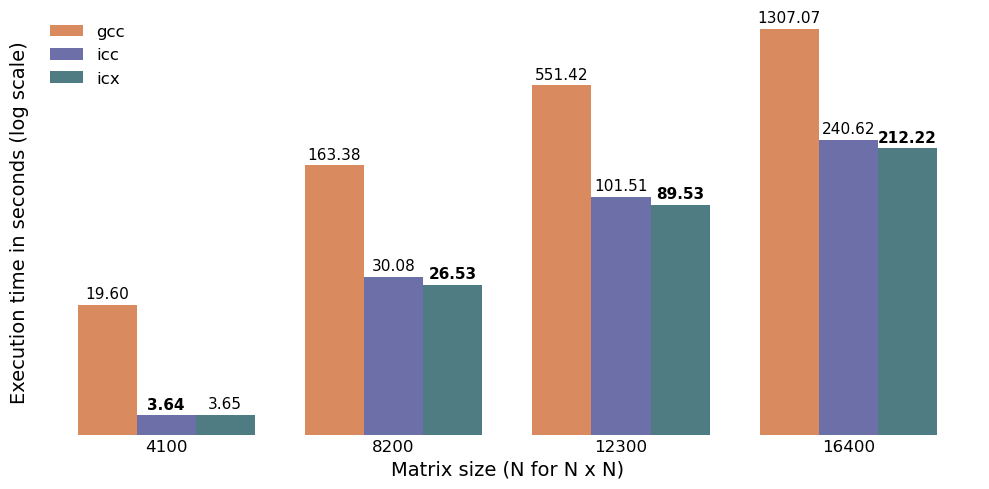

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DATA FROM THE TABLE - TIME ONLY
# ============================================================
selected_sizes = [4100, 8200, 12300, 16400]

data = {
    "gcc": {
        4100: 19.60,
        8200: 163.38,
        12300: 551.42,
        16400: 1307.07,
    },
    "icc": {
        4100: 3.64,
        8200: 30.08,
        12300: 101.51,
        16400: 240.62,
    },
    "icx": {
        4100: 3.65,
        8200: 26.53,
        12300: 89.53,
        16400: 212.22,
    },
}

series = ["gcc", "icc", "icx"]

colors = [
    "#D98B5F",  # gcc
    "#6C6FA8",  # icc
    "#4F7C82",  # icx
]

# ============================================================
# PLOT
# ============================================================
x = np.arange(len(selected_sizes))
bar_width = 0.26

fig, ax = plt.subplots(figsize=(10, 5))

all_bars = []
all_values = []

for j, label in enumerate(series):
    values = [data[label][n] for n in selected_sizes]
    offset = (j - 1) * bar_width

    bars = ax.bar(
        x + offset,
        values,
        width=bar_width,
        label=label,
        color=colors[j],
        edgecolor="none"
    )

    all_bars.append(bars)
    all_values.append(values)

# ============================================================
# STYLE
# ============================================================
ax.set_yscale("log")
ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
ax.set_ylabel("Execution time in seconds (log scale)", fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in selected_sizes], fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.set_yticks([])
ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)
ax.tick_params(axis="x", length=0)
ax.grid(False)

ax.legend(frameon=False, loc="upper left", fontsize=12)

# ============================================================
# VALUE LABELS
# bold = minimum time in each N group
# ============================================================
for i in range(len(selected_sizes)):
    group_values = [all_values[k][i] for k in range(len(series))]
    best_value = min(group_values)

    for bars, values in zip(all_bars, all_values):
        value = values[i]
        bar = bars[i]

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value * 1.05,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold" if np.isclose(value, best_value) else "normal"
        )

plt.tight_layout()
plt.show()

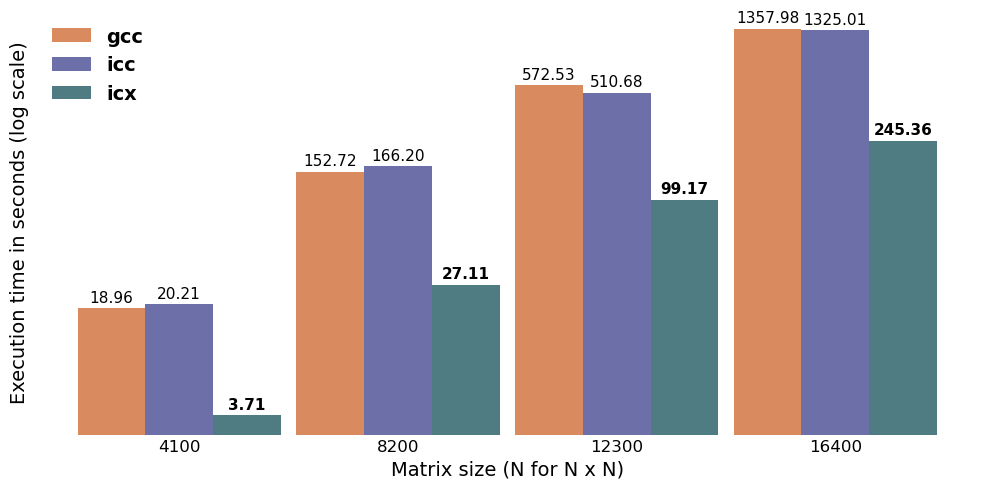

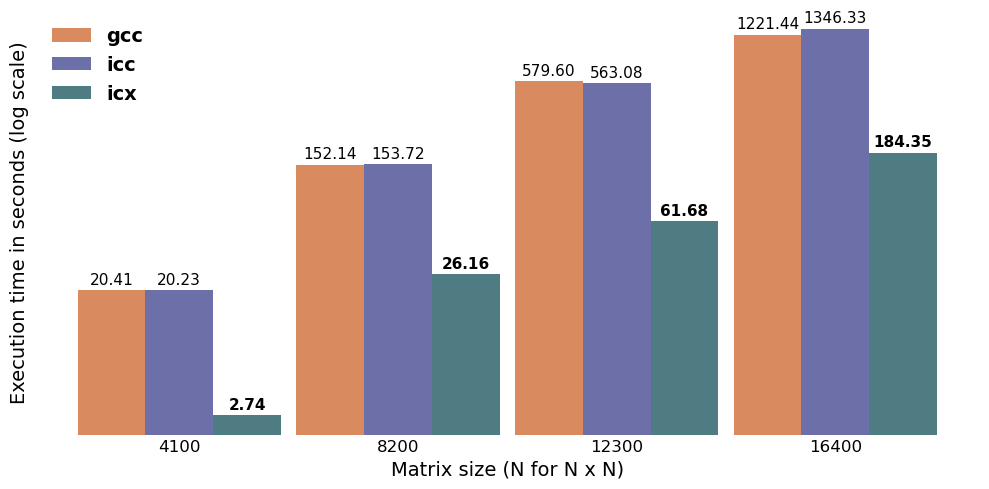

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("benchmark_results_seq.csv")

colors = [
    "#D98B5F",  # gcc
    "#6C6FA8",  # icc
    "#4F7C82",  # icx
]

selected_sizes = [4100, 8200, 12300, 16400]
compilers = ["gcc", "icc", "icx"]

# The two configurations you want
configs = [(0, 0), (1, 1)]

bar_width = 0.31
x = np.arange(len(selected_sizes))

for align, restrict in configs:
    filtered = df[
        (df["Test"] == "seq-ikj") &
        (df["Compiler"].isin(compilers)) &
        (df["N"].isin(selected_sizes)) &
        (df["Align"] == align) &
        (df["Restrict"] == restrict)
    ].copy()

    gcc_times = []
    icc_times = []
    icx_times = []

    for n in selected_sizes:
        gcc_row = filtered[(filtered["N"] == n) & (filtered["Compiler"] == "gcc")]
        icc_row = filtered[(filtered["N"] == n) & (filtered["Compiler"] == "icc")]
        icx_row = filtered[(filtered["N"] == n) & (filtered["Compiler"] == "icx")]

        gcc_times.append(gcc_row["Time_s"].iloc[0] if not gcc_row.empty else np.nan)
        icc_times.append(icc_row["Time_s"].iloc[0] if not icc_row.empty else np.nan)
        icx_times.append(icx_row["Time_s"].iloc[0] if not icx_row.empty else np.nan)

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    bars_gcc = ax.bar(x - bar_width, gcc_times, width=bar_width, label="gcc", color=colors[0], edgecolor="none")
    bars_icc = ax.bar(x,             icc_times, width=bar_width, label="icc", color=colors[1], edgecolor="none")
    bars_icx = ax.bar(x + bar_width, icx_times, width=bar_width, label="icx", color=colors[2], edgecolor="none")

    ax.set_yscale("log")
    ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
    ax.set_ylabel("Execution time in seconds (log scale)", fontsize=14)
    #ax.set_title(f"Align={align}, Restrict={restrict}", fontsize=14)

    ax.set_xticks(x)
    ax.set_xticklabels([str(n) for n in selected_sizes], fontsize=12)

    ax.set_yticks([])
    ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis="x", length=0)
    ax.grid(False)

    ax.legend(frameon=False, loc="upper left", prop={"size": 14, "weight": "bold"})

    # Value labels, bold the minimum in each N group
    for i in range(len(selected_sizes)):
        values = [gcc_times[i], icc_times[i], icx_times[i]]
        min_value = np.nanmin(values)
        current_bars = [bars_gcc[i], bars_icc[i], bars_icx[i]]

        for bar, value in zip(current_bars, values):
            if not np.isnan(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value * 1.05,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold" if value == min_value else "normal"
                )

    plt.tight_layout()
    plt.show()

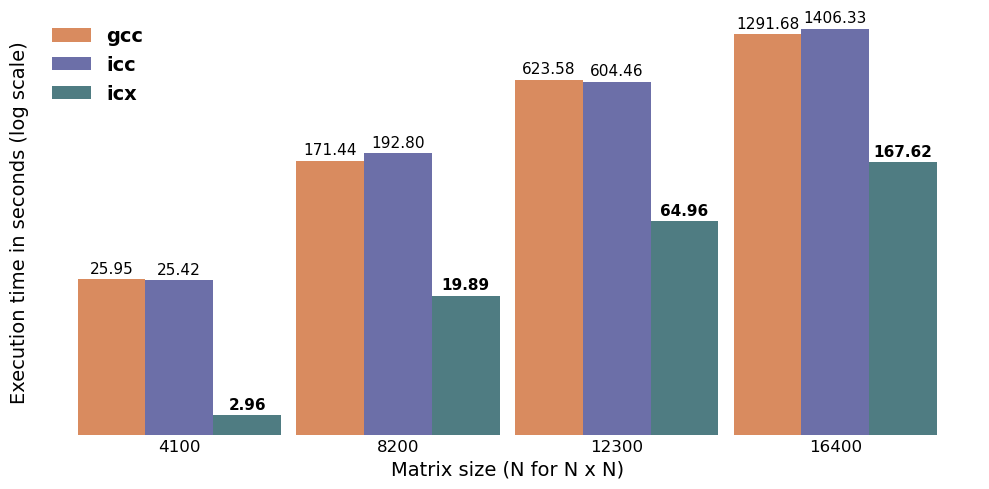

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("benchmark_results_seq.csv")

# Custom color palette
colors = [
    "#D98B5F",  # warm orange
    "#6C6FA8",  # muted purple
    "#4F7C82",  # desaturated teal
]

selected_sizes = [4100, 8200, 12300, 16400]

filtered = df[
    (df["Test"] == "seq-pad") &
    (df["Compiler"].isin(["gcc", "icc", "icx"])) &
    (df["N"].isin(selected_sizes))
].copy()

filtered = filtered.sort_values(["N", "Compiler"])

bar_width = 0.31
x = np.arange(len(selected_sizes))

plt.figure(figsize=(10, 5))
ax = plt.gca()

gcc_times = []
icc_times = []
icx_times = []

for n in selected_sizes:
    gcc_row = filtered[(filtered["N"] == n) & (filtered["Compiler"] == "gcc")]
    icc_row = filtered[(filtered["N"] == n) & (filtered["Compiler"] == "icc")]
    icx_row = filtered[(filtered["N"] == n) & (filtered["Compiler"] == "icx")]

    gcc_times.append(gcc_row["Time_s"].iloc[0] if not gcc_row.empty else np.nan)
    icc_times.append(icc_row["Time_s"].iloc[0] if not icc_row.empty else np.nan)
    icx_times.append(icx_row["Time_s"].iloc[0] if not icx_row.empty else np.nan)

bars_gcc = ax.bar(
    x - bar_width,
    gcc_times,
    width=bar_width,
    label="gcc",
    color=colors[0],
    edgecolor="none"
)

bars_icc = ax.bar(
    x,
    icc_times,
    width=bar_width,
    label="icc",
    color=colors[1],
    edgecolor="none"
)

bars_icx = ax.bar(
    x + bar_width,
    icx_times,
    width=bar_width,
    label="icx",
    color=colors[2],
    edgecolor="none"
)

# Log scale on Y axis
ax.set_yscale("log")

# Titles and labels
ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
ax.set_ylabel("Execution time in seconds (log scale)", fontsize=14)

# X ticks
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in selected_sizes], fontsize=12)

# Remove everything on Y axis except the label
ax.set_yticks([])
ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)

# Remove black axis lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Remove X tick marks but keep labels
ax.tick_params(axis="x", length=0)

# Remove grid
ax.grid(False)

# Legend
ax.legend(frameon=False, loc="upper left", prop={"size": 14, "weight": "bold"})

# Add value labels and bold the minimum value in each matrix-size group
for i in range(len(selected_sizes)):
    values = [gcc_times[i], icc_times[i], icx_times[i]]
    min_value = np.nanmin(values)

    current_bars = [bars_gcc[i], bars_icc[i], bars_icx[i]]

    for bar, value in zip(current_bars, values):
        if not np.isnan(value):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value * 1.05,
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold" if value == min_value else "normal"
            )

plt.tight_layout()
plt.show()

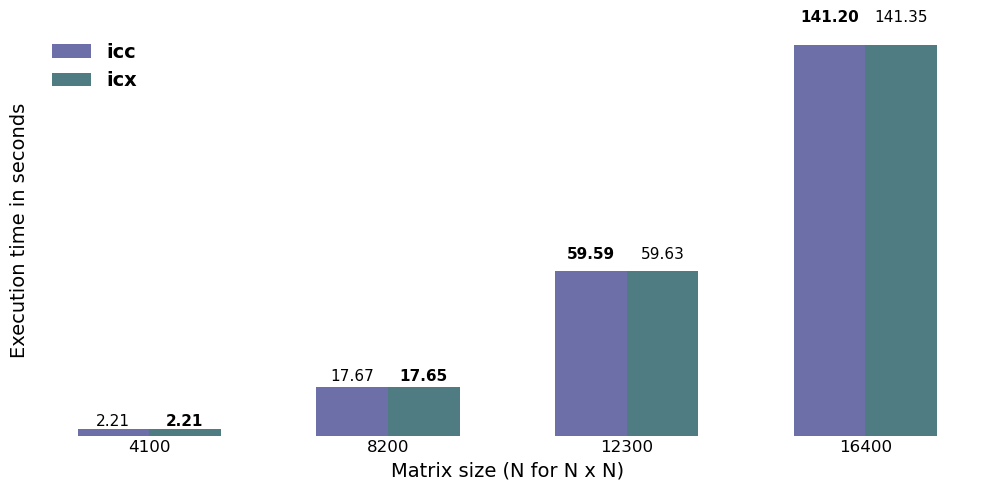

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("benchmark_results_seq.csv")

# Custom color palette
colors = [
    "#6C6FA8",  # icc
    "#4F7C82",  # icx
]

selected_sizes = [4100, 8200, 12300, 16400]

filtered = df[
    (df["Test"] == "mkl-seq") &
    (df["Compiler"].isin(["icc", "icx"])) &
    (df["N"].isin(selected_sizes))
].copy()

filtered = filtered.sort_values(["N", "Compiler"])

bar_width = 0.30
x = np.arange(len(selected_sizes))


fig, ax = plt.subplots(figsize=(10, 5))

icc_times = []
icx_times = []

for n in selected_sizes:
    icc_row = filtered[(filtered["Compiler"] == "icc") & (filtered["N"] == n)]
    icx_row = filtered[(filtered["Compiler"] == "icx") & (filtered["N"] == n)]

    icc_times.append(icc_row["Time_s"].iloc[0] if not icc_row.empty else np.nan)
    icx_times.append(icx_row["Time_s"].iloc[0] if not icx_row.empty else np.nan)

# Barre affiancate
bars_icc = ax.bar(
        x,
        icc_times,
        width=bar_width,
        label="icc",
        color=colors[0],
        edgecolor="none"
    )

bars_icx = ax.bar(
        x + bar_width,
        icx_times,
        width=bar_width,
        label="icx",
        color=colors[1],
        edgecolor="none"
    )


ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
ax.set_ylabel("Execution time in seconds", fontsize=14)

    # X ticks centrati sul gruppo di 2 barre
ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels([str(n) for n in selected_sizes], fontsize=12)

    # Remove everything on Y axis except the label
ax.set_yticks([])
ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)

    # Remove black axis lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

    # Remove X tick marks but keep labels
ax.tick_params(axis="x", length=0)

    # Remove grid
ax.grid(False)

    # Legend
ax.legend(frameon=False, loc="upper left", prop={"size": 14, "weight": "bold"})

    # Add value labels centered INSIDE each bar
    # Bold the minimum value between icc and icx for each matrix size
for i in range(len(selected_sizes)):
        values = [icc_times[i], icx_times[i]]
        min_value = np.nanmin(values)

        current_bars = [bars_icc[i], bars_icx[i]]

        for bar, value in zip(current_bars, values):
            if not np.isnan(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value * 1.05,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold" if value == min_value else "normal"
                )

plt.tight_layout()
plt.show()

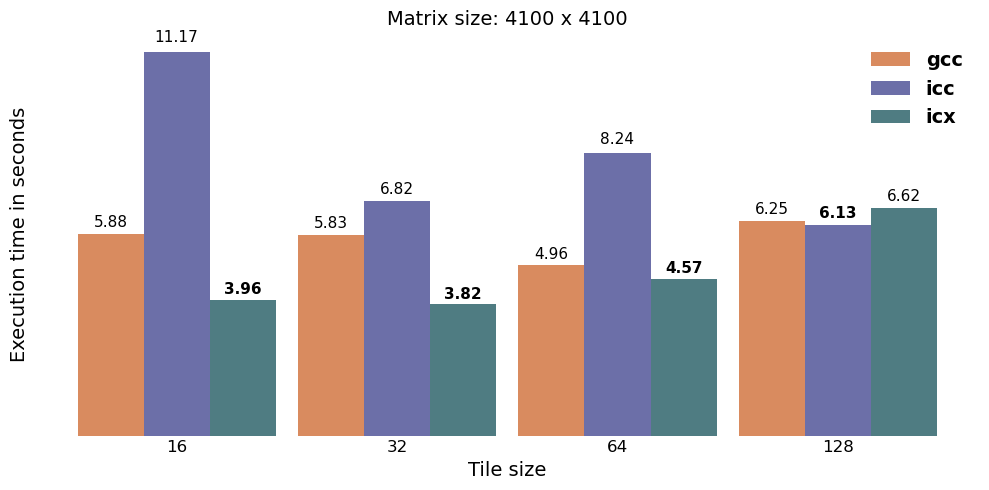

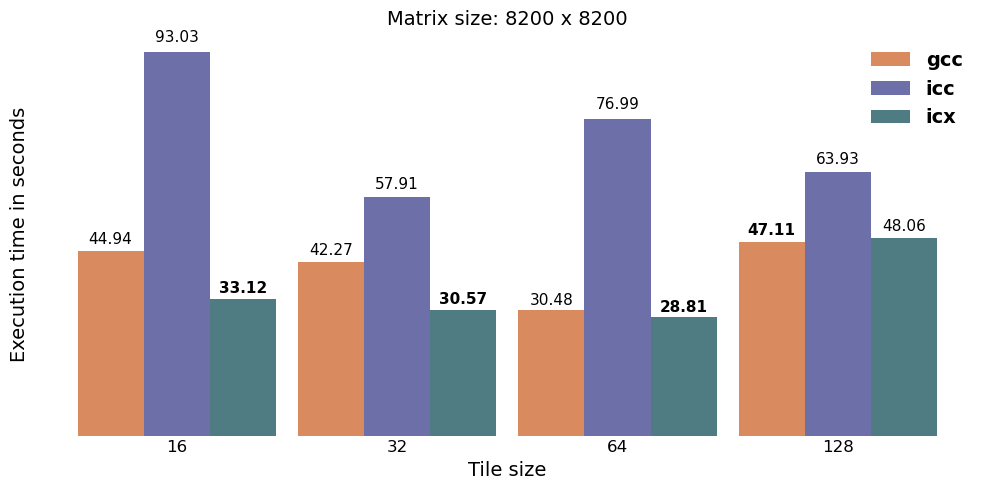

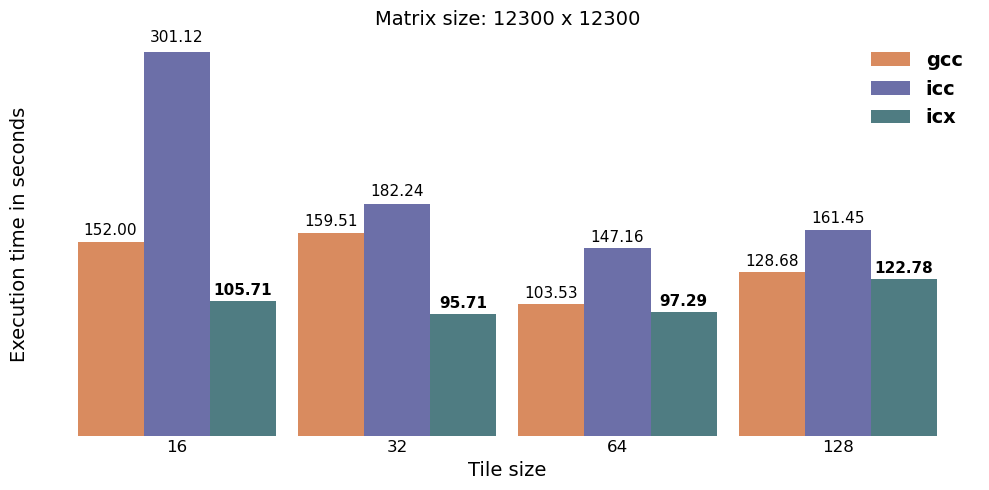

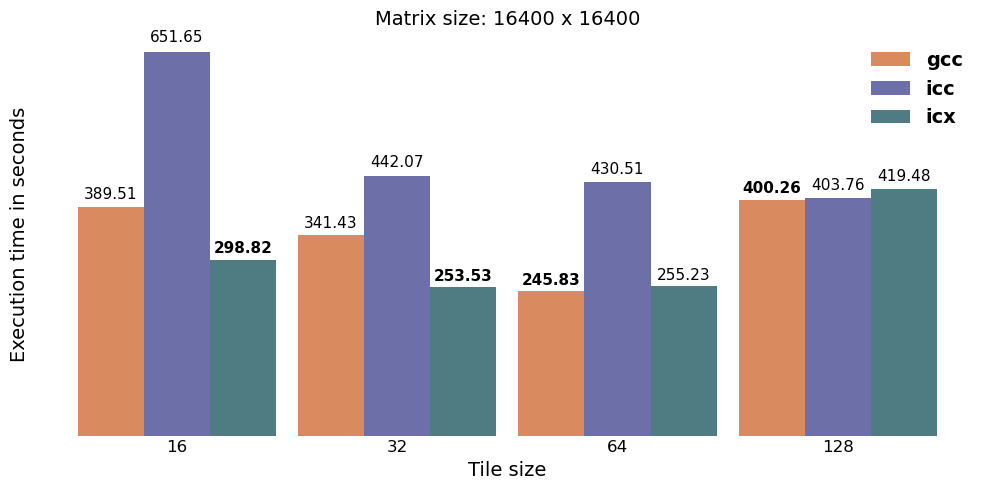

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv("benchmark_results_seq.csv")

# Normalize columns
df = df.rename(columns={
    "CPU": "cpu",
    "Compiler": "compiler",
    "Test": "test",
    "N": "n",
    "Align": "align",
    "Restrict": "restrict",
    "Threads/Ranks": "threads",
    "TileSize": "tile_size",
    "Time_s": "time_s",
})

df["compiler"] = df["compiler"].astype(str).str.strip().str.lower()
df["test"] = df["test"].astype(str).str.strip().str.lower()
df["n"] = pd.to_numeric(df["n"], errors="coerce")
df["threads"] = pd.to_numeric(df["threads"], errors="coerce")
df["tile_size"] = pd.to_numeric(df["tile_size"], errors="coerce")
df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")

# Custom color palette
colors = {
    "gcc": "#D98B5F",
    "icc": "#6C6FA8",
    "icx": "#4F7C82",
}

selected_sizes = [4100, 8200, 12300, 16400]
tile_categories = [16, 32, 64, 128]
compilers = ["gcc", "icc", "icx"]

# Filter only tiled test, single thread
filtered = df[
    (df["test"].str.contains("tile", na=False)) &
    (df["threads"] == 1) &
    (df["n"].isin(selected_sizes)) &
    (df["tile_size"].isin(tile_categories)) &
    (df["compiler"].isin(compilers)) &
    (df["align"] == 1) &
    (df["restrict"] == 1)
].copy()

bar_width = 0.3
x = np.arange(len(tile_categories))

for n_val in selected_sizes:
    sub = filtered[filtered["n"] == n_val]

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    gcc_times = []
    icc_times = []
    icx_times = []

    for tile in tile_categories:
        gcc_row = sub[(sub["tile_size"] == tile) & (sub["compiler"] == "gcc")]
        icc_row = sub[(sub["tile_size"] == tile) & (sub["compiler"] == "icc")]
        icx_row = sub[(sub["tile_size"] == tile) & (sub["compiler"] == "icx")]

        gcc_times.append(gcc_row["time_s"].iloc[0] if not gcc_row.empty else np.nan)
        icc_times.append(icc_row["time_s"].iloc[0] if not icc_row.empty else np.nan)
        icx_times.append(icx_row["time_s"].iloc[0] if not icx_row.empty else np.nan)

    bars_gcc = ax.bar(
        x - bar_width,
        gcc_times,
        width=bar_width,
        label="gcc",
        color=colors["gcc"],
        edgecolor="none"
    )

    bars_icc = ax.bar(
        x,
        icc_times,
        width=bar_width,
        label="icc",
        color=colors["icc"],
        edgecolor="none"
    )

    bars_icx = ax.bar(
        x + bar_width,
        icx_times,
        width=bar_width,
        label="icx",
        color=colors["icx"],
        edgecolor="none"
    )

    # Log scale on Y axis
    #ax.set_yscale("log")

    ax.set_title(f"Matrix size: {n_val} x {n_val}", fontsize=14)
    ax.set_xlabel("Tile size", fontsize=14)
    ax.set_ylabel("Execution time in seconds", fontsize=14)

    ax.set_xticks(x)
    ax.set_xticklabels([str(t) for t in tile_categories], fontsize=12)

    ax.set_yticks([])
    
    # Remove black axis lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Remove tick marks
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0)

    # Remove grid
    ax.grid(False)

    # Legend
    ax.legend(frameon=False, loc="upper right", prop={"size": 14, "weight": "bold"})

    # Add value labels and bold minimum for each tile
    for i in range(len(tile_categories)):
        values = [gcc_times[i], icc_times[i], icx_times[i]]
        valid_values = [v for v in values if not np.isnan(v)]

        if len(valid_values) == 0:
            continue

        min_value = min(valid_values)
        current_bars = [bars_gcc[i], bars_icc[i], bars_icx[i]]

        for bar, value in zip(current_bars, values):
            if not np.isnan(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value * 1.02,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold" if value == min_value else "normal"
                )

    plt.tight_layout()
    plt.show()


===== N = 4100 =====
TILE -> 3.823 s | icx, tile=32
 PAD -> 2.956 s | icx
 IKJ -> 2.738 s | icx, align=1, restrict=1
 MKL -> 2.212 s | icx


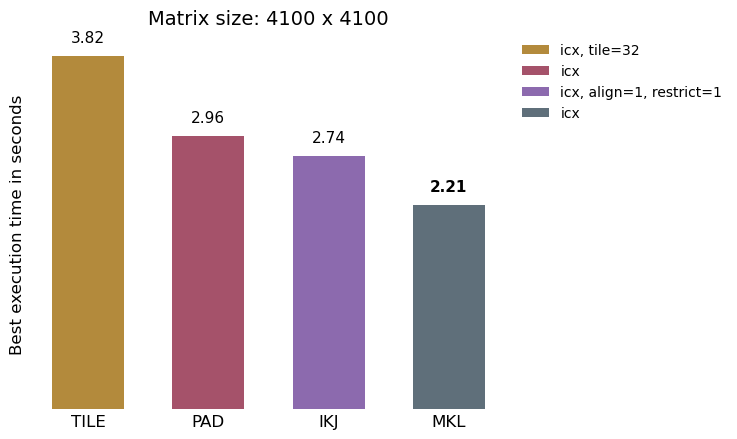


===== N = 8200 =====
TILE -> 28.811 s | icx, tile=64
 PAD -> 19.888 s | icx
 IKJ -> 26.157 s | icx, align=1, restrict=1
 MKL -> 17.654 s | icx


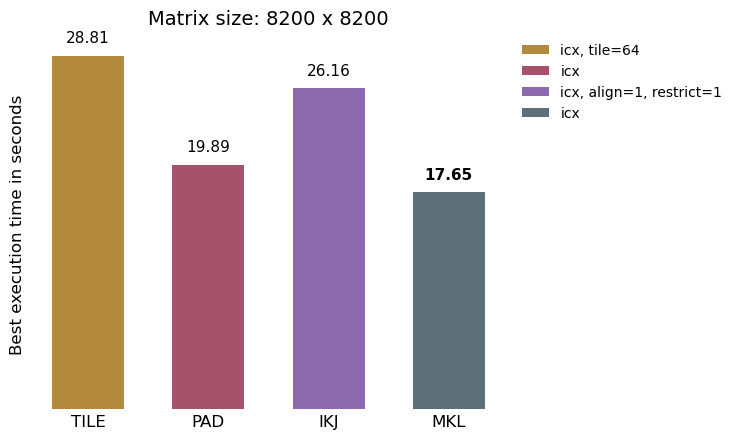


===== N = 12300 =====
TILE -> 95.712 s | icx, tile=32
 PAD -> 64.960 s | icx
 IKJ -> 61.678 s | icx, align=1, restrict=1
 MKL -> 59.589 s | icc


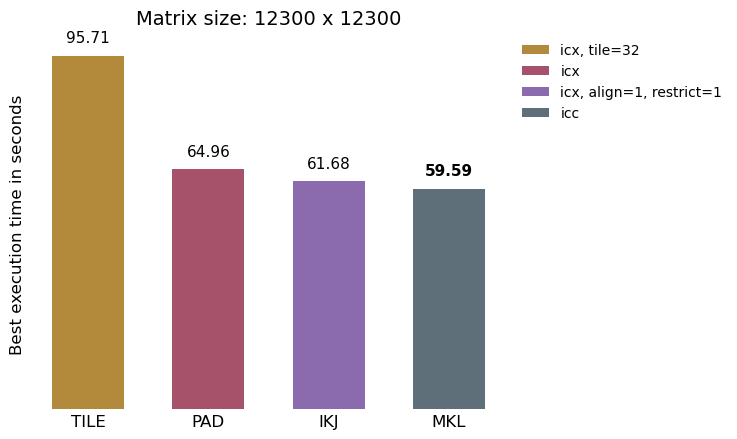


===== N = 16400 =====
TILE -> 245.830 s | gcc, tile=64
 PAD -> 167.617 s | icx
 IKJ -> 184.346 s | icx, align=1, restrict=1
 MKL -> 141.197 s | icc


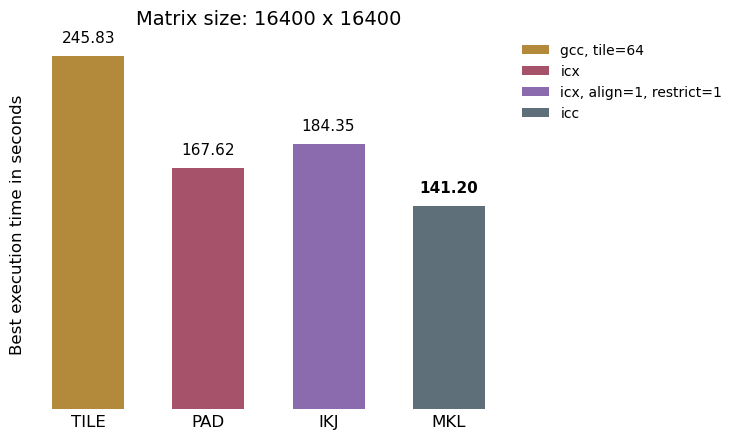

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# INPUT
# ============================================================
csv_file = "benchmark_results_seq.csv"
selected_sizes = [4100, 8200, 12300, 16400]

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(csv_file)

# ============================================================
# CLEAN COLUMNS
# ============================================================
df["Compiler"] = df["Compiler"].astype(str).str.strip().str.lower()
df["Test"] = df["Test"].astype(str).str.strip().str.lower()

df["N"] = pd.to_numeric(df["N"], errors="coerce")
df["Align"] = pd.to_numeric(df["Align"], errors="coerce")
df["Restrict"] = pd.to_numeric(df["Restrict"], errors="coerce")
df["Threads/Ranks"] = pd.to_numeric(df["Threads/Ranks"], errors="coerce")
df["Time_s"] = pd.to_numeric(df["Time_s"], errors="coerce")
df["TileSize_num"] = pd.to_numeric(df["TileSize"], errors="coerce")  # "-" -> NaN

# ============================================================
# CLASSIFY APPROACH
# ============================================================
def classify_approach(row):
    test_name = row["Test"]
    tile_num = row["TileSize_num"]

    if "mkl" in test_name:
        return "mkl"
    if "pad" in test_name:
        return "pad"
    if ("tile" in test_name) or np.isfinite(tile_num):
        return "tile"
    if "ikj" in test_name:
        return "ikj"
    return "other"

df["approach"] = df.apply(classify_approach, axis=1)

# Teniamo solo gli approcci che ci interessano
approaches = ["tile", "pad", "ikj", "mkl"]
df = df[df["approach"].isin(approaches)].copy()

# ============================================================
# COLORS
# ============================================================
colors = {
    "tile": "#B38A3C",
    "pad":  "#A5526A",
    "ikj":  "#8C6AAE",
    "mkl":  "#5F6F7A",
}

# ============================================================
# STYLE
# ============================================================
def minimal_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.set_yticks([])
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)
    ax.grid(False)

# ============================================================
# BEST SELECTION FUNCTIONS
# ============================================================
def get_best_tile(sub):
    """
    Migliore TILE per un dato N:
    - tra tutti i compiler
    - tra tutti i TileSize
    """
    tmp = sub[
        (sub["approach"] == "tile")
    ].dropna(subset=["Time_s"]).copy()

    if tmp.empty:
        return np.nan, None

    idx = tmp["Time_s"].idxmin()
    return float(tmp.loc[idx, "Time_s"]), tmp.loc[idx]


def get_best_pad(sub):
    """
    PAD solo con compiler = icx
    """
    tmp = sub[
        (sub["approach"] == "pad") &
        (sub["Compiler"] == "icx")
    ].dropna(subset=["Time_s"]).copy()

    if tmp.empty:
        return np.nan, None

    idx = tmp["Time_s"].idxmin()
    return float(tmp.loc[idx, "Time_s"]), tmp.loc[idx]


def get_best_ikj(sub):
    """
    IKJ:
    confronta solo queste due configurazioni:
      - Align=0, Restrict=0
      - Align=1, Restrict=1

    e sceglie la migliore tra tutti i compiler.
    """
    tmp = sub[
        (sub["approach"] == "ikj") &
        (
            ((sub["Align"] == 0) & (sub["Restrict"] == 0)) |
            ((sub["Align"] == 1) & (sub["Restrict"] == 1))
        )
    ].dropna(subset=["Time_s"]).copy()

    if tmp.empty:
        return np.nan, None

    idx = tmp["Time_s"].idxmin()
    return float(tmp.loc[idx, "Time_s"]), tmp.loc[idx]


def get_best_mkl(sub):
    """
    Migliore MKL per un dato N.
    """
    tmp = sub[
        (sub["approach"] == "mkl")
    ].dropna(subset=["Time_s"]).copy()

    if tmp.empty:
        return np.nan, None

    idx = tmp["Time_s"].idxmin()
    return float(tmp.loc[idx, "Time_s"]), tmp.loc[idx]


def get_best_rows(sub):
    return {
        "tile": get_best_tile(sub),
        "pad":  get_best_pad(sub),
        "ikj":  get_best_ikj(sub),
        "mkl":  get_best_mkl(sub),
    }

# ============================================================
# LABELS FOR LEGEND
# ============================================================
def format_cfg(row, approach):
    if row is None:
        return "no data"

    compiler = row["Compiler"]

    if approach == "tile":
        tile_size = int(row["TileSize_num"]) if pd.notna(row["TileSize_num"]) else None
        if tile_size is not None:
            return f"{compiler}, tile={tile_size}"
        return f"{compiler}"

    if approach == "ikj":
        align = int(row["Align"]) if pd.notna(row["Align"]) else None
        restrict = int(row["Restrict"]) if pd.notna(row["Restrict"]) else None
        if align is not None and restrict is not None:
            return f"{compiler}, align={align}, restrict={restrict}"
        return f"{compiler}"

    if approach == "pad":
        return f"{compiler}"

    if approach == "mkl":
        return f"{compiler}"

    return f"{compiler}"

# ============================================================
# MAIN LOOP
# ============================================================
for N in selected_sizes:
    sub = df[df["N"] == N].copy()

    if sub.empty:
        print(f"N = {N}: no data")
        continue

    best = get_best_rows(sub)
    times = [best[a][0] for a in approaches]
    finite_times = [t for t in times if np.isfinite(t)]

    print(f"\n===== N = {N} =====")
    for a in approaches:
        t, row = best[a]
        if np.isfinite(t):
            print(f"{a.upper():>4} -> {t:.3f} s | {format_cfg(row, a)}")
        else:
            print(f"{a.upper():>4} -> no data")

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    x = np.arange(len(approaches))
    bars = ax.bar(
        x,
        times,
        color=[colors[a] for a in approaches],
        edgecolor="none",
        width=0.60
    )

    ax.set_title(f"Matrix size: {N} x {N}", fontsize=14, pad=10)
    ax.set_ylabel("Best execution time in seconds", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([a.upper() for a in approaches], fontsize=12)

    # Legend
    legend_handles = []
    legend_labels = []

    for i, a in enumerate(approaches):
        t, row = best[a]
        legend_handles.append(bars[i])

        if np.isfinite(t):
            legend_labels.append(format_cfg(row, a))
        else:
            legend_labels.append(f"{a.upper()} — no data")

    ax.legend(
        legend_handles,
        legend_labels,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=10,
        borderaxespad=0
    )

    # Values on top of bars
    if finite_times:
        best_time = min(finite_times)
        max_time = max(finite_times)
        offset = max_time * 0.03
    else:
        best_time = None
        offset = 0.0

    for bar, t in zip(bars, times):
        if np.isfinite(t):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                t + offset,
                f"{t:.2f}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold" if (best_time is not None and np.isclose(t, best_time)) else "normal"
            )

    minimal_style(ax)
    plt.tight_layout()
    plt.show()